In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go


## Topic Analysis

In [20]:
topic_summary = pd.read_csv(r"..\data\processed\github_topic_summary.csv")


In [21]:
topic_summary.head()


,final_topic,category,repository_count,total_stars,average_stars,median_stars,maximum_stars,total_forks,average_forks,total_watchers,average_watchers,maximum_watchers,total_open_issues,average_open_issues,average_repo_size,first_created_year,last_created_year
0,python,Python & Developer Tools,2317,5906440,2549.175658,25.0,193888,779652,336.492016,5906440,2549.175658,193888,80099,34.570134,50782.601208,2020,2026
1,machine-learning,AI & Machine Learning,1986,2070190,1042.391742,186.0,73526,263615,132.736657,2070190,1042.391742,73526,46589,23.458711,66540.686808,2020,2026
2,data-science,Data Science & Analytics,1416,464473,328.017655,25.0,47720,54207,38.281780,464473,328.017655,47720,17831,12.592514,61766.282486,2020,2026
3,web,Web Development,1400,263664,188.331429,4.0,165139,43678,31.198571,263664,188.331429,165139,6097,4.355000,14678.208571,2020,2026
4,artificial-intelligence,AI & Machine Learning,782,5281282,6753.557545,270.0,249399,736203,941.436061,5281282,6753.557545,249399,102681,131.305627,100506.209719,2020,2026


In [22]:
top_topics = topic_summary.sort_values(by="repository_count", ascending=False).head(10)
top_topics


,final_topic,category,repository_count,total_stars,average_stars,median_stars,maximum_stars,total_forks,average_forks,total_watchers,average_watchers,maximum_watchers,total_open_issues,average_open_issues,average_repo_size,first_created_year,last_created_year
0,python,Python & Developer Tools,2317,5906440,2549.175658,25.0,193888,779652,336.492016,5906440,2549.175658,193888,80099,34.570134,50782.601208,2020,2026
1,machine-learning,AI & Machine Learning,1986,2070190,1042.391742,186.0,73526,263615,132.736657,2070190,1042.391742,73526,46589,23.458711,66540.686808,2020,2026
2,data-science,Data Science & Analytics,1416,464473,328.017655,25.0,47720,54207,38.281780,464473,328.017655,47720,17831,12.592514,61766.282486,2020,2026
3,web,Web Development,1400,263664,188.331429,4.0,165139,43678,31.198571,263664,188.331429,165139,6097,4.355000,14678.208571,2020,2026
4,artificial-intelligence,AI & Machine Learning,782,5281282,6753.557545,270.0,249399,736203,941.436061,5281282,6753.557545,249399,102681,131.305627,100506.209719,2020,2026
5,deep-learning,AI & Machine Learning,732,2042929,2790.886612,380.0,165139,287807,393.178962,2042929,2790.886612,165139,41020,56.038251,99514.851093,2020,2026
6,large-language-models,AI & Machine Learning,568,6053364,10657.330986,631.0,249399,869185,1530.255282,6053364,10657.330986,249399,119748,210.823944,82205.128521,2020,2026
7,pytorch,AI & Machine Learning,477,2059339,4317.272537,497.0,165139,310663,651.285115,2059339,4317.272537,165139,57431,120.400419,62029.742138,2020,2026
8,natural-language-processing,AI & Machine Learning,267,689494,2582.374532,185.0,75080,83730,313.595506,689494,2582.374532,75080,9705,36.348315,50113.011236,2020,2026
9,computer-vision,AI & Machine Learning,207,532180,2570.917874,351.0,62046,82197,397.086957,532180,2570.917874,62046,8391,40.536232,177932.584541,2020,2026


In [23]:
duplicate_topics = topic_summary["final_topic"].duplicated().sum()
print(f"No. of Duplicate topics:{duplicate_topics}")


No. of Duplicate topics:0


In [24]:
topic_summary.shape


(13079, 17)

In [25]:
repo_count_topics = topic_summary.sort_values(
    by="repository_count", ascending=False
).head(10)


In [26]:
fig = px.bar(
    repo_count_topics,
    x=repo_count_topics["repository_count"],
    y=repo_count_topics["final_topic"],
    orientation="h",
)
fig.show()


In [27]:
top_topics_stars = topic_summary.sort_values(by="total_stars", ascending=False).head(10)


In [28]:
fig = px.scatter(
    data_frame=top_topics_stars,
    x="total_stars",
    y="final_topic",
    size="repository_count",
    hover_name="final_topic",
    labels={
        "total_stars": "Total Stars",
        "final_topic": "Topic",
        "repository_count": "Repositories",
    },
)
fig.show()


In [29]:
top_category_repo_count = (
    topic_summary[topic_summary["category"] != "General Python & Open Source"]
    .groupby("category")["repository_count"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)


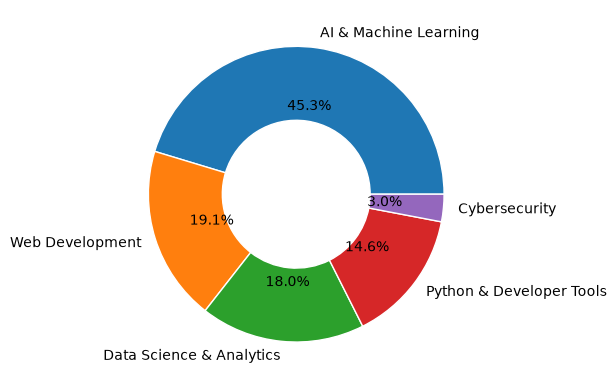

In [30]:
plt.pie(
    top_category_repo_count["repository_count"],
    labels=top_category_repo_count["category"],
    autopct="%1.1f%%",
    wedgeprops={"width": 0.5, "edgecolor": "white"},
)
plt.show()


In [31]:
top_category_stars = (
    topic_summary.groupby("category")["total_stars"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .iloc[::-1]
)
top_category_stars


category
Finance & Trading                 1195680
DevOps & Cloud                    1201187
Cybersecurity                     1633776
Software Development              1692849
Data Science & Analytics          2152675
Automation & Agents               3034810
Web Development                   4667564
Python & Developer Tools          6825137
AI & Machine Learning            45729553
General Python & Open Source    119515080
Name: total_stars, dtype: int64

In [32]:
y_cats = top_category_stars.index
x_vals = top_category_stars.values
fig = go.Figure()
for y, x in zip(y_cats, x_vals):
    fig.add_trace(
        go.Scatter(
            x=[0, x],
            y=[y, y],
            mode="lines",
            line={"color": "skyblue", "width": 2},
            showlegend=False,
        )
    )
fig.add_trace(
    go.Scatter(
        x=x_vals,
        y=y_cats,
        mode="markers",
        marker={"size": 12, "color": "blue"},
    )
)

fig.update_layout(
    title="Top Categories by Stars",
    xaxis_title="Stars",
    yaxis_title="Category",
    template="plotly_white",
    height=500,
)

fig.show()
